This cell imports all necessary libraries for the project, including tools for file/utility operations, data handling (NumPy, Pandas), visualization (Matplotlib, Seaborn), deep learning with PyTorch and timm, and machine learning/evaluation utilities from scikit-learn. It also includes tqdm for progress tracking and kagglehub/Path for downloading and managing Kaggle datasets, then prints a confirmation message.

In [1]:
import os
import shutil
import random
import itertools
import time
import platform
import re
import joblib
import tempfile


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from scipy.special import softmax
from sklearn.manifold import TSNE

from tqdm import tqdm

import kagglehub
from pathlib import Path

print("All libraries imported successfully.")


All libraries imported successfully.


This block imports core utilities for file handling, timing, copying objects, JSON/CSV processing, randomness, system checks, and resource monitoring (psutil), along with libraries for data analysis and visualization (NumPy, Pandas, Matplotlib, Seaborn). It also brings in image-processing tools (OpenCV and PIL) and the main PyTorch/torchvision components needed to build models, apply transforms, and load data efficiently using Dataset and DataLoader.

In [2]:
import os
import time
import copy
import json
import random
import platform
import csv
import psutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import PIL
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader



This section checks the current Kaggle runtime environment.
It collects and displays:
CPU model using the platform library
Total RAM (in GB) using psutil
GPU name via the nvidia-smi command (if a GPU is available)

In [3]:
import psutil

cpu_info = platform.processor()
ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: No GPU available


This code organizes PM25Vision images by air-quality labels.
It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.
Finally, it prints summary counts and skipped files — readying the dataset for training.

In [4]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/datasets/deadcardassian/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)


df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


This block organizes the test images into the same labeled structure as the training dataset.
It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.
Duplicate files are checked and renamed if needed, while missing images are skipped.
Finally, it prints a summary of copied, skipped, and renamed files.

In [5]:
TEST_CSV_PATH = Path("/kaggle/input/datasets/deadcardassian/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/datasets/deadcardassian/pm25vision/test/images")
OUT_DIR       = Path("/kaggle/working/dataset") 


AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None 

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None  
    lo = int(m.group(1))
    return aqi_to_label(lo)


df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

 
    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
     
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


This code counts the number of images in each air-quality class under /kaggle/working/dataset/.
It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.

In [6]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103


This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.
It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.
Useful for quick checks, visualization, or later data-loader creation.

In [7]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/790293189670104.jpg,Good
1,/kaggle/working/dataset/Good/149387074721270.jpg,Good
2,/kaggle/working/dataset/Good/338432581231657.jpg,Good
3,/kaggle/working/dataset/Good/273234448339854.jpg,Good
4,/kaggle/working/dataset/Good/525706415232158.jpg,Good
5,/kaggle/working/dataset/Good/1134775623653629.jpg,Good
6,/kaggle/working/dataset/Good/934171517417032.jpg,Good
7,/kaggle/working/dataset/Good/138001895355763.jpg,Good
8,/kaggle/working/dataset/Good/501650530975098.jpg,Good
9,/kaggle/working/dataset/Good/920412168752394.jpg,Good


This code visualizes the number of images in each air-quality category using a Seaborn bar chart.
It helps verify dataset balance and ensure all classes are properly represented before training.

Ephoch Number Declaration

/tmp/ipykernel_17/3663135084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["label"].value_counts().index,


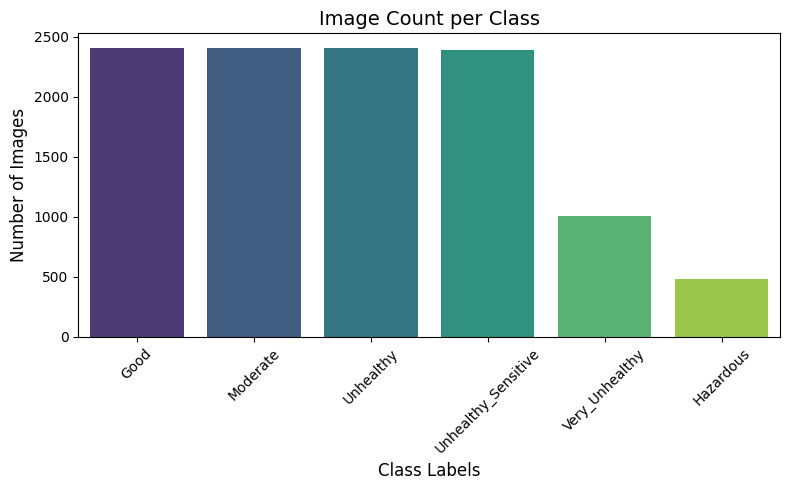

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This code displays a small gallery showing two random sample images from each air-quality class.
It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.
Useful for quick quality checks and understanding visual variation before model training.

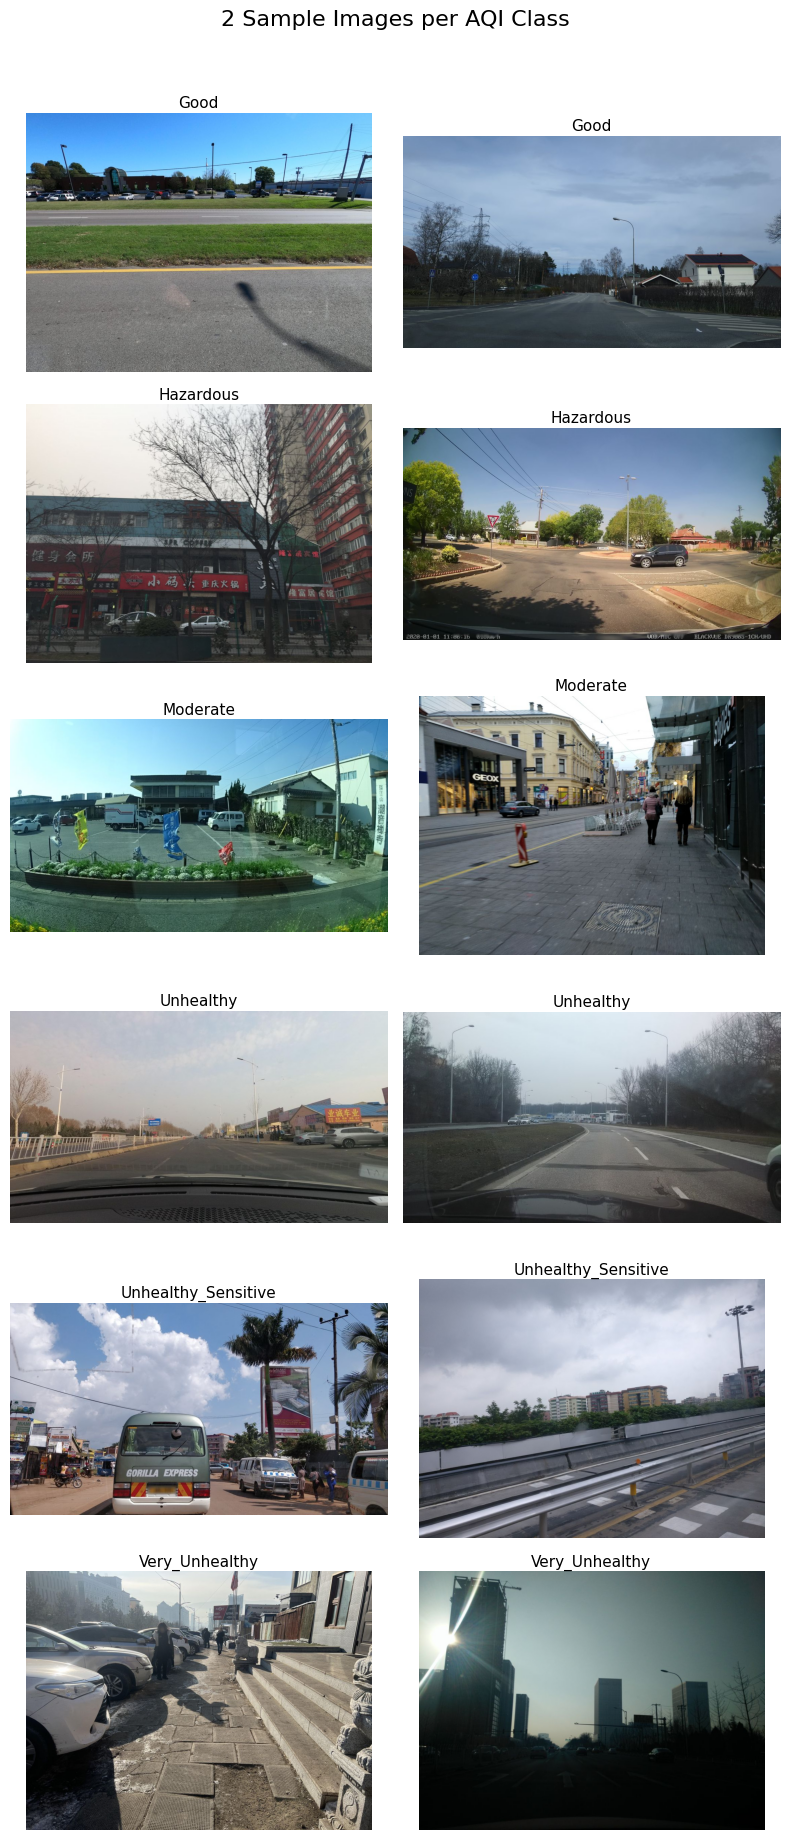

In [9]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).
Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.
From the training portion, 10% is further used as validation.
All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio

In [10]:
original_base_dir = "/kaggle/working/dataset"
new_base_dir = "/kaggle/working/final_data"

data = []
for label in os.listdir(original_base_dir):
    path = os.path.join(original_base_dir, label)
    if not os.path.isdir(path):
        continue
    for fname in os.listdir(path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG')):
            data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)

print(f"Total images: {len(df)}")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))


Total images: 11103
Train: 8992, Val: 1000, Test: 1111


This code sets a fixed random seed (42) for PyTorch (CPU and CUDA), NumPy, and Python’s random module to make training and other randomized operations more reproducible across runs.

In [11]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


This section defines a custom PyTorch Dataset (ImageDataset) that loads images from file paths, converts them to RGB, applies optional preprocessing/augmentation transforms, and returns each image with its label. It also provides a helper function get_dinov2_transforms() to create DINOv2-style transforms: heavier augmentations for training (flip, rotation, color jitter) and a simpler resize + normalization pipeline for evaluation.

In [12]:
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    """Custom dataset for image classification"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dinov3_transforms(is_training=False, img_size=224):

    if is_training:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])


This block builds a DINOv2-based image classification model using a pretrained Vision Transformer from timm. First, DINOv2FeatureExtractor loads the pretrained DINOv2 ViT backbone, optionally freezes its weights to prevent fine-tuning, and outputs feature embeddings. Then, DINOv2Classifier wraps that backbone with a lightweight classification head (LayerNorm → Dropout → Linear) to produce class logits, and also provides a get_features() method to extract embeddings without running the classifier.

In [13]:
class DINOv3FeatureExtractor(nn.Module):
    def __init__(self, model_name='vit_base_patch16_dinov3.lvd1689m', pretrained=True, freeze_backbone=True):
        super().__init__()

        # Load pretrained DINOv3 model (timm)
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        return self.backbone(x)


class DINOv3Classifier(nn.Module):
    def __init__(self, num_classes, model_name='vit_base_patch16_dinov3.lvd1689m',
                 pretrained=True, freeze_backbone=True, dropout=0.1):
        super().__init__()

        self.feature_extractor = DINOv3FeatureExtractor(
            model_name=model_name,
            pretrained=pretrained,
            freeze_backbone=freeze_backbone
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_extractor.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_extractor.feature_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        return self.feature_extractor(x)


This section defines a create_model() helper that builds a DINOv2-based classifier using different ViT backbone sizes (small/base/large/giant) and optionally freezes the backbone for feature-extraction training. The example __main__ block then sets basic training settings (batch size, image size, device), creates the model, moves it to GPU/CPU, runs a quick forward pass on a dummy image to verify output and feature shapes, and prints total vs trainable (unfrozen) parameter counts to confirm freezing worked.

In [14]:
def create_model(num_classes, freeze_backbone=True, model_variant='base'):

    model_names = {
        'small': 'vit_small_patch16_dinov3.lvd1689m',
        'base':  'vit_base_patch16_dinov3.lvd1689m',
        'large': 'vit_large_patch16_dinov3.lvd1689m',
        'giant': 'vit_huge_patch16_dinov3.lvd1689m'   # if not available in your env, use 'vit_large...'
    }

    model_name = model_names.get(model_variant, model_names['base'])

    model = DINOv3Classifier(
        num_classes=num_classes,
        model_name=model_name,
        pretrained=True,
        freeze_backbone=freeze_backbone,
        dropout=0.1
    )
    return model


if __name__ == "__main__":
    BATCH_SIZE = 32
    IMG_SIZE = 512  # <-- changed from 518 (patch16-friendly)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    _num_classes_placeholder = 10

    model = create_model(
        num_classes=_num_classes_placeholder,
        freeze_backbone=True,
        model_variant='base'
    )
    model = model.to(DEVICE)

    print("Model created successfully!")
    print(f"Feature dimension: {model.feature_extractor.feature_dim}")
    print(f"Number of classes: {_num_classes_placeholder}")

    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        output = model(dummy_input)
        features = model.get_features(dummy_input)

    print(f"Output shape: {output.shape}")
    print(f"Features shape: {features.shape}")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Model created successfully!
Feature dimension: 768
Number of classes: 10
Output shape: torch.Size([1, 10])
Features shape: torch.Size([1, 768])
Total parameters: 85,650,442
Trainable parameters: 9,226
Frozen parameters: 85,641,216


This block initializes key global settings by reading the training folder to detect class names, computing NUM_CLASSES, and creating class-to-index/index-to-class mappings for label encoding. It also selects the runtime device (GPU if available), instantiates a frozen-backbone DINOv2 “base” model on that device, and sets common training constants like batch size and image size.

In [15]:
base_folder = "/kaggle/working/final_data/train"
all_class_dirs = sorted(os.listdir(base_folder))

NUM_CLASSES = len(all_class_dirs)
print(f"Global NUM_CLASSES set to: {NUM_CLASSES}")

class_to_idx = {class_name: i for i, class_name in enumerate(all_class_dirs)}
idx_to_class = {i: class_name for class_name, i in class_to_idx.items()}

print("Class mapping:", class_to_idx)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

m_model = create_model(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
    model_variant='base'
).to(DEVICE)

print("Global DINOv3 model instantiated.")
BATCH_SIZE = 32
IMG_SIZE = 512


Global NUM_CLASSES set to: 6
Class mapping: {'Good': 0, 'Hazardous': 1, 'Moderate': 2, 'Unhealthy': 3, 'Unhealthy_Sensitive': 4, 'Very_Unhealthy': 5}
Using device: cpu
Global DINOv3 model instantiated.


This block builds the train/validation/test pipelines by scanning each split directory, collecting image file paths and their class labels into Pandas DataFrames, and converting the string labels into integer IDs using class_to_idx. It then applies DINOv2-style transforms (augmented for training, standard for validation/testing), wraps the data in the custom ImageDataset, and finally creates PyTorch DataLoaders with the chosen batch size and shuffling settings, confirming that all loaders are ready.

In [16]:
train_dir = "/kaggle/working/final_data/train"
val_dir = "/kaggle/working/final_data/val"
test_dir = "/kaggle/working/final_data/test"

train_df = []
for label in os.listdir(train_dir):
    for f in os.listdir(os.path.join(train_dir, label)):
        train_df.append({"path": os.path.join(train_dir, label, f), "label": label})
train_df = pd.DataFrame(train_df)

val_df = []
for label in os.listdir(val_dir):
    for f in os.listdir(os.path.join(val_dir, label)):
        val_df.append({"path": os.path.join(val_dir, label, f), "label": label})
val_df = pd.DataFrame(val_df)

test_df = []
for label in os.listdir(test_dir):
    for f in os.listdir(os.path.join(test_dir, label)):
        test_df.append({"path": os.path.join(test_dir, label, f), "label": label})
test_df = pd.DataFrame(test_df)

def prepare_data_lists(dataframe, class_to_idx):
    return dataframe["path"].tolist(), [class_to_idx[x] for x in dataframe["label"]]

train_image_paths, train_labels_int = prepare_data_lists(train_df, class_to_idx)
val_image_paths, val_labels_int = prepare_data_lists(val_df, class_to_idx)
test_image_paths, test_labels_int = prepare_data_lists(test_df, class_to_idx)

train_transform = get_dinov3_transforms(is_training=True, img_size=IMG_SIZE)
val_transform = get_dinov3_transforms(is_training=False, img_size=IMG_SIZE)

train_dataset = ImageDataset(train_image_paths, train_labels_int, train_transform)
val_dataset = ImageDataset(val_image_paths, val_labels_int, val_transform)
test_dataset = ImageDataset(test_image_paths, test_labels_int, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train, Val, Test loaders ready.")


Train, Val, Test loaders ready.


This block creates a full embedding-visualization pipeline for your DINOv2 model. It first defines extract_embeddings() (run in inference mode with @torch.no_grad()) to loop through a DataLoader and collect either the classifier head outputs (logits) or the backbone feature vectors into NumPy arrays. Then it defines visualize_tsne() to reduce those embeddings to 2D using t-SNE and plot them with colors per class (optionally showing class names on the colorbar and saving the figure). Finally, run_tsne_analysis() runs the whole process twice—once for logits and once for backbone features—generating and saving both t-SNE plots, and the __main__ example applies this to the test set and also compares multiple perplexity values by plotting several t-SNE projections side by side.


Using current DINOv3Classifier model weights.

Extracting Classification Head Output (Logits, 6-dim)


Extracting embeddings: 100%|██████████| 35/35 [46:09<00:00, 79.14s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Logits embedding shape: (1111, 6)
Labels shape: (1111,)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1111 samples in 0.008s...
[t-SNE] Computed neighbors for 1111 samples in 0.048s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1111
[t-SNE] Computed conditional probabilities for sample 1111 / 1111
[t-SNE] Mean sigma: 0.229489
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.781250
[t-SNE] KL divergence after 1000 iterations: 1.365136
Saved: tsne_logits_test.png


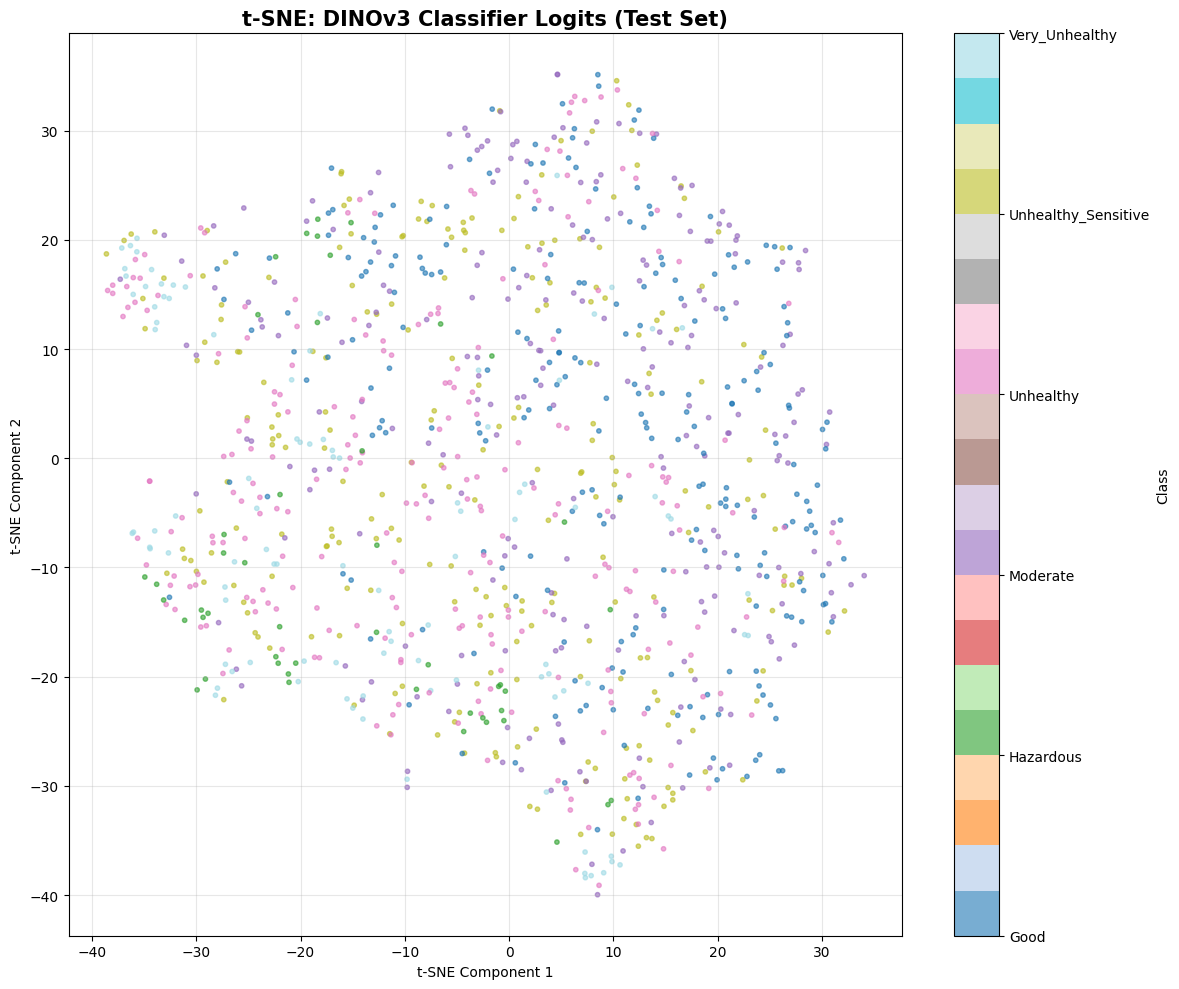


Extracting DINOv3 Backbone Features (768-dim)


Extracting embeddings: 100%|██████████| 35/35 [45:46<00:00, 78.48s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Backbone embedding shape: (1111, 768)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1111 samples in 0.002s...
[t-SNE] Computed neighbors for 1111 samples in 0.282s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1111
[t-SNE] Computed conditional probabilities for sample 1111 / 1111
[t-SNE] Mean sigma: 1.392184
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.160683
[t-SNE] KL divergence after 1000 iterations: 1.143095
Saved: tsne_features_test.png


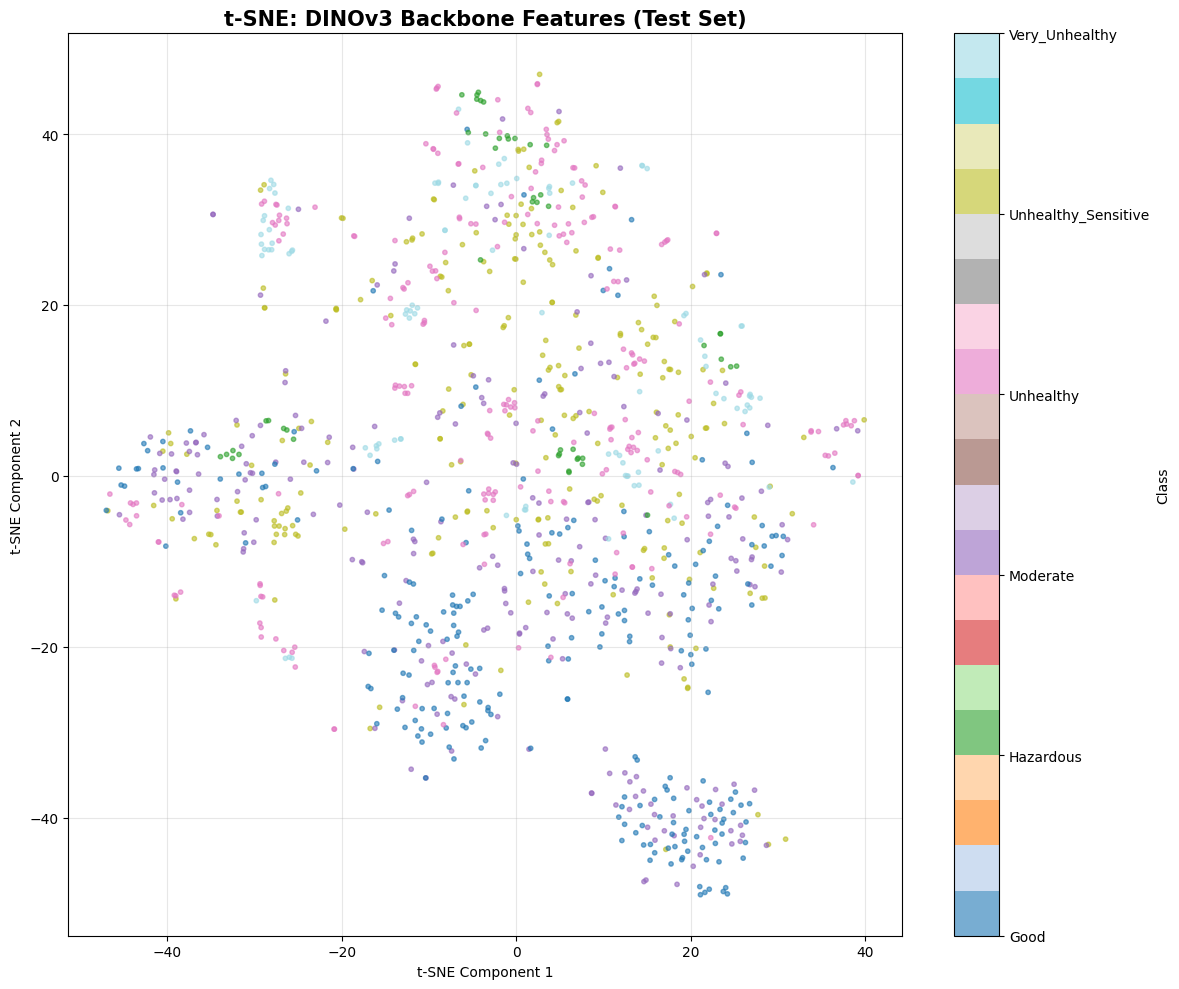


Comparing Different Perplexity Values for DINOv3 Backbone Features


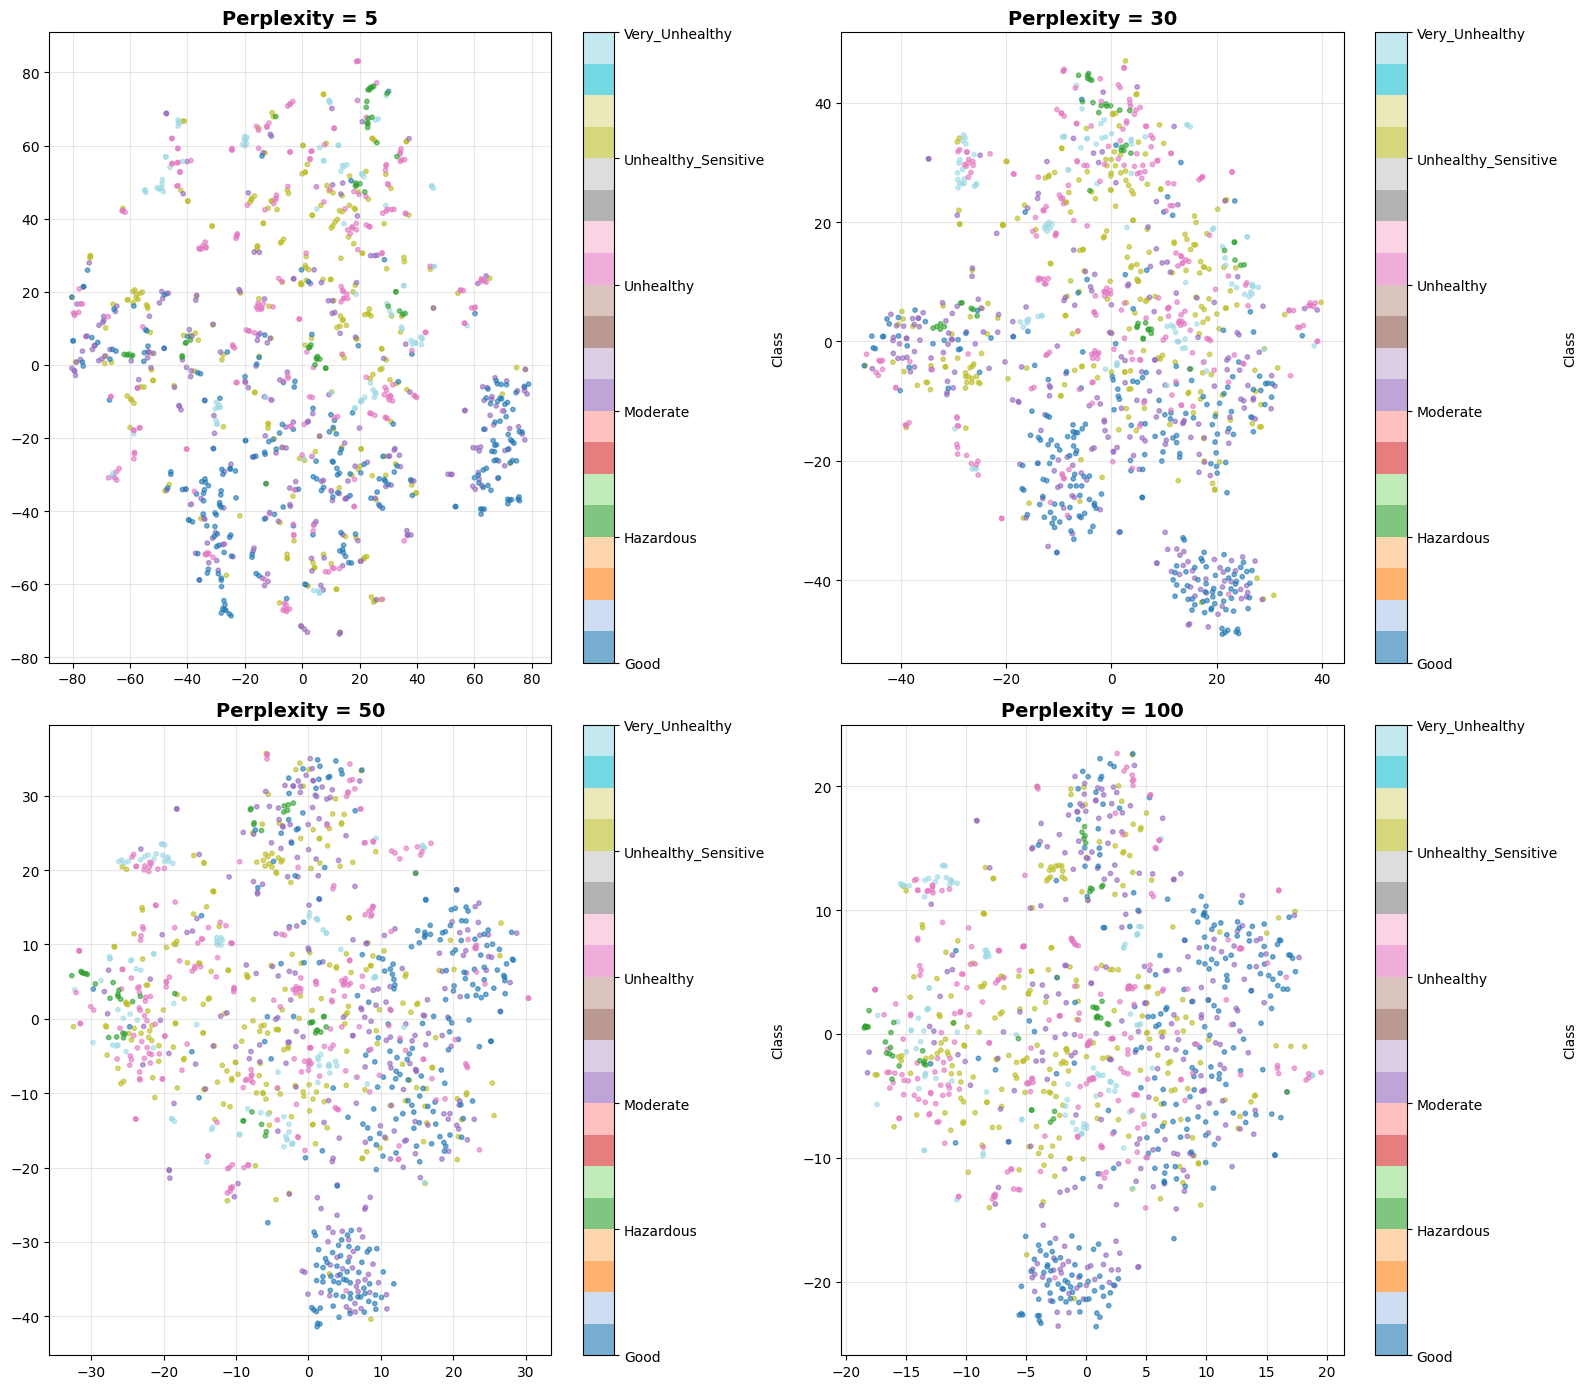


✅ t-SNE analysis complete!


In [17]:
@torch.no_grad()
def extract_embeddings(model, loader, device, use_classifier_output=True):
    
    model.eval()
    all_embeddings = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(device)

        if use_classifier_output:
            embeddings = model(images)
        else:
            embeddings = model.get_features(images)

        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

    embeddings = np.vstack(all_embeddings)
    labels = np.concatenate(all_labels)

    return embeddings, labels

def visualize_tsne(embeddings, labels, title="t-SNE Visualization",
                   perplexity=30, n_iter=1000, random_state=42,
                   figsize=(12, 10), save_path=None, class_names=None):
    

    print(f"\nRunning t-SNE with perplexity={perplexity}...")

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        random_state=random_state,
        verbose=1
    )
    embeddings_2d = tsne.fit_transform(embeddings)


    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels,
        cmap='tab20',
        alpha=0.6,
        s=10
    )

    if class_names is not None:
        cbar = plt.colorbar(scatter, ticks=np.unique(labels), label='Class')
        cbar.set_ticklabels([class_names[i] for i in np.unique(labels)])
    else:
        plt.colorbar(scatter, label='Class')

    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()

    return embeddings_2d


def run_tsne_analysis(model, loader, device, dataset_name="Test", class_names=None):

    print("\nUsing current DINOv3Classifier model weights.")

    print("\n" + "="*60)
    print(f"Extracting Classification Head Output (Logits, {model.classifier[2].out_features}-dim)")
    print("="*60)

    logits_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=True
    )

    print("Logits embedding shape:", logits_embeddings.shape)
    print("Labels shape:", labels.shape)

    visualize_tsne(
        logits_embeddings,
        labels,
        title=f"t-SNE: DINOv3 Classifier Logits ({dataset_name} Set)",
        save_path=f"tsne_logits_{dataset_name.lower()}.png",
        class_names=class_names
    )

    print("\n" + "="*60)
    print(f"Extracting DINOv3 Backbone Features ({model.feature_extractor.feature_dim}-dim)")
    print("="*60)

    feature_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=False
    )

    print("Backbone embedding shape:", feature_embeddings.shape)

    visualize_tsne(
        feature_embeddings,
        labels,
        title=f"t-SNE: DINOv3 Backbone Features ({dataset_name} Set)",
        save_path=f"tsne_features_{dataset_name.lower()}.png",
        class_names=class_names
    )

    return logits_embeddings, feature_embeddings, labels


if __name__ == "__main__":

    sorted_class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    logits_emb, feature_emb, test_labels = run_tsne_analysis(
        m_model,
        test_loader,
        DEVICE,
        dataset_name="Test",
        class_names=sorted_class_names
    )

    print("\n" + "="*60)
    print("Comparing Different Perplexity Values for DINOv3 Backbone Features")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    perplexities = [5, 30, 50, 100]

    for idx, perp in enumerate(perplexities):
        ax = axes[idx // 2, idx % 2]

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            random_state=42
        )

        emb_2d = tsne.fit_transform(feature_emb)

        scatter = ax.scatter(
            emb_2d[:, 0],
            emb_2d[:, 1],
            c=test_labels,
            cmap='tab20',
            alpha=0.6,
            s=10
        )

        ax.set_title(f"Perplexity = {perp}", fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

        if sorted_class_names is not None:
            cbar = plt.colorbar(scatter, ax=ax, ticks=np.unique(test_labels), label='Class')
            cbar.set_ticklabels([sorted_class_names[i] for i in np.unique(test_labels)])

    plt.tight_layout()
    plt.savefig("tsne_perplexity_comparison_dinov2_features.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ t-SNE analysis complete!")


This function switches the model to evaluation mode and iterates through the dataloader without tracking gradients, extracting DINOv2 backbone feature embeddings using model.get_features() for each batch. It collects all feature vectors and labels, moves them to CPU, converts them to NumPy arrays, concatenates everything into full dataset-level arrays, and returns the final (features, labels) pair.

In [18]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)

            feats = model.get_features(images)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels


This block turns the DINOv2 model into a feature extractor and then trains classic machine-learning classifiers on those extracted embeddings. It first extracts backbone features for the train and validation sets, standardizes them with StandardScaler, and optionally compresses them with PCA to 512 dimensions. After that, it trains and evaluates four classifiers—MLP, linear SVM, Decision Tree, and Random Forest—on the reduced features and prints each model’s validation accuracy.

In [19]:
train_X, train_y = extract_features(m_model, train_loader, DEVICE)
val_X, val_y = extract_features(m_model, val_loader, DEVICE)
test_X, test_y = extract_features(m_model, test_loader, DEVICE)

X_all = np.concatenate([train_X, val_X, test_X], axis=0)
y_all = np.concatenate([train_y, val_y, test_y], axis=0)

tr, te = 60, 20

print("\n" + "="*80)
print(f"SPLIT RATIO: {tr}:{te}")
print("="*80)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all,
    y_all,
    test_size=te / 100,
    stratify=y_all,
    random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

pca = PCA(n_components=512)
X_tr = pca.fit_transform(X_tr)
X_te = pca.transform(X_te)

classifiers = {
    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42,
        verbose=False
    ),
    "SVM": SVC(kernel="linear", probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

for name, model in classifiers.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    acc = accuracy_score(y_te, preds)
    print(f"\n{name} Accuracy ({tr}:{te}): {acc * 100:.2f}%")

    print("Classification Report:")
    print(classification_report(
        y_te,
        preds,
        target_names=[idx_to_class[i] for i in range(NUM_CLASSES)],
        digits=3
    ))

Extracting features: 100%|██████████| 35/35 [45:50<00:00, 78.58s/it]



SPLIT RATIO: 60:20

MLP Accuracy (60:20): 71.59%
Classification Report:
                     precision    recall  f1-score   support

               Good      0.674     0.732     0.702       482
          Hazardous      0.838     0.865     0.851        96
           Moderate      0.593     0.541     0.566       482
          Unhealthy      0.837     0.813     0.825       481
Unhealthy_Sensitive      0.691     0.710     0.700       479
     Very_Unhealthy      0.814     0.806     0.810       201

           accuracy                          0.716      2221
          macro avg      0.741     0.745     0.742      2221
       weighted avg      0.715     0.716     0.715      2221


SVM Accuracy (60:20): 60.11%
Classification Report:
                     precision    recall  f1-score   support

               Good      0.623     0.718     0.667       482
          Hazardous      0.664     0.781     0.718        96
           Moderate      0.498     0.473     0.485       482
          Unheal

This block generates multi-class ROC curves for each trained classifier (MLP, SVM, Decision Tree, Random Forest) using the validation set. For each model, it obtains class-wise probability scores (via predict_proba() when available, otherwise converting the SVM decision scores to probabilities with softmax), binarizes the true labels using one-vs-rest encoding, and then computes and plots an ROC curve and AUC for every class with the class names shown in the legend.


ROC CURVE — SPLIT 60:20

ROC Curve for MLP — Split 60:20


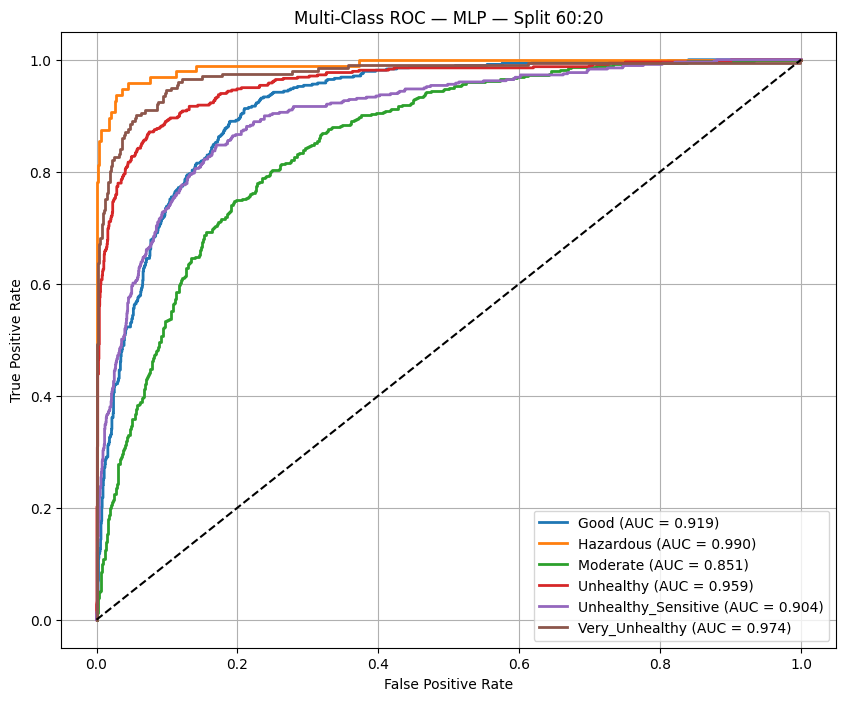


ROC Curve for SVM — Split 60:20


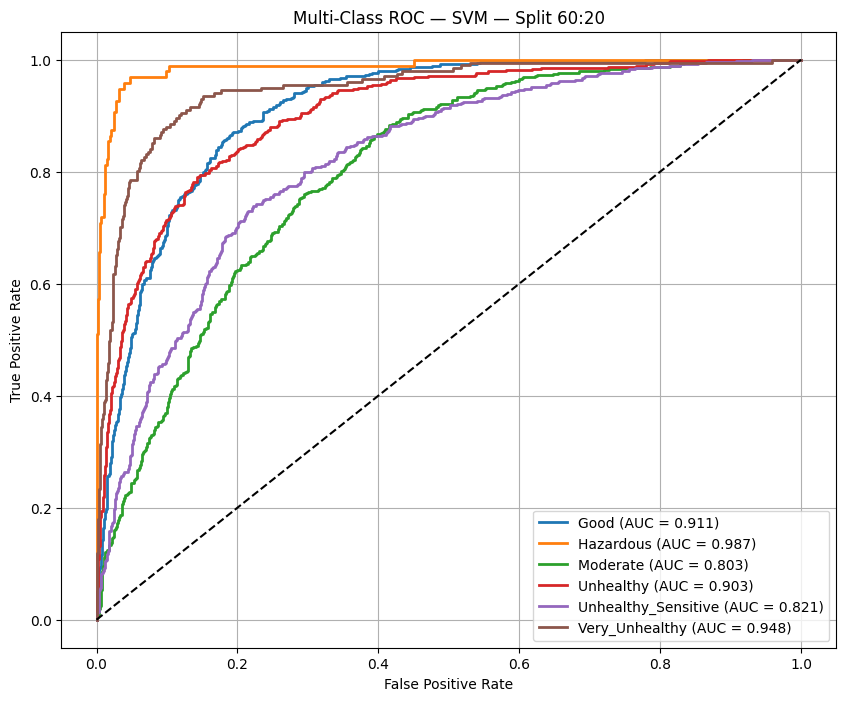


ROC Curve for Decision Tree — Split 60:20


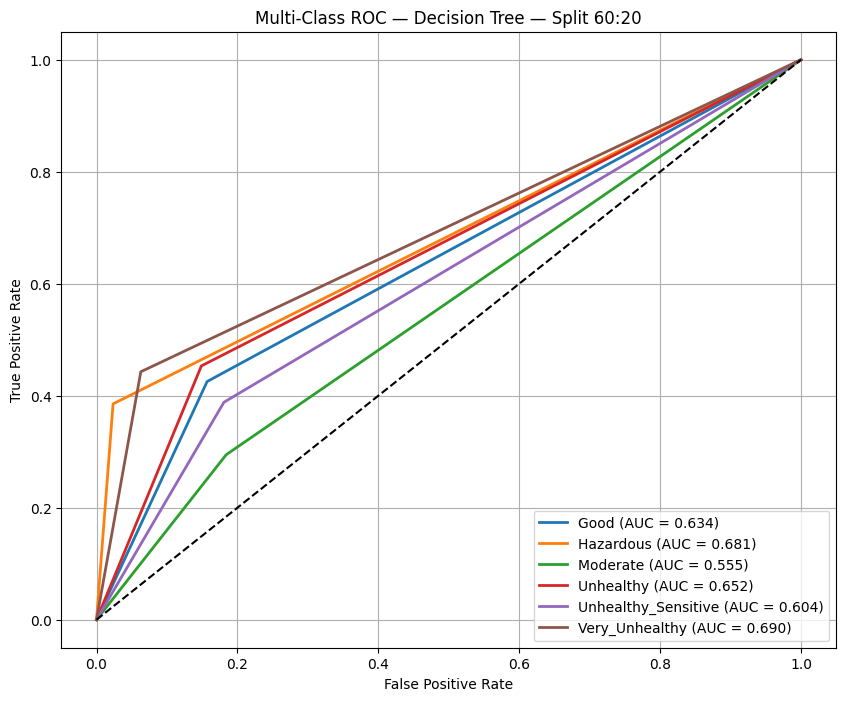


ROC Curve for Random Forest — Split 60:20


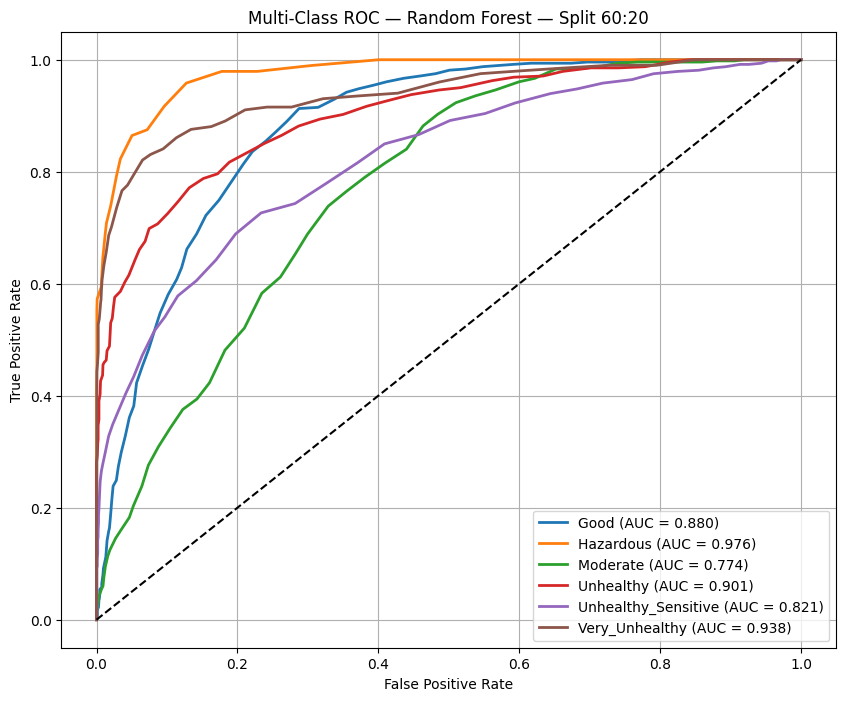

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.special import softmax
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*90)
print(f"ROC CURVE — SPLIT {tr}:{te}")
print("="*90)

y_bin = label_binarize(y_te, classes=list(range(NUM_CLASSES)))

for name, model in classifiers.items():

    print(f"\n======================")
    print(f"ROC Curve for {name} — Split {tr}:{te}")
    print(f"======================")

    model.fit(X_tr, y_tr)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_te)
    else:
        probs = softmax(model.decision_function(X_te), axis=1)

    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{idx_to_class[i]} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC — {name} — Split {tr}:{te}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

This block evaluates each trained classifier (MLP, SVM, Decision Tree, Random Forest) on the validation set by generating predictions, computing overall accuracy, and calculating per-class accuracy by filtering validation samples class-wise. It then prints a detailed classification_report (precision/recall/F1 per class) and visualizes the confusion matrix for each model using a Seaborn heatmap with class names on both axes.


EVALUATION Confusion Matrix — Split 60:20

------------------------------
MLP — Split 60:20
------------------------------
Accuracy (MLP) — Split 60:20: 71.59%

Classification Report:
                     precision    recall  f1-score   support

               Good      0.674     0.732     0.702       482
          Hazardous      0.838     0.865     0.851        96
           Moderate      0.593     0.541     0.566       482
          Unhealthy      0.837     0.813     0.825       481
Unhealthy_Sensitive      0.691     0.710     0.700       479
     Very_Unhealthy      0.814     0.806     0.810       201

           accuracy                          0.716      2221
          macro avg      0.741     0.745     0.742      2221
       weighted avg      0.715     0.716     0.715      2221



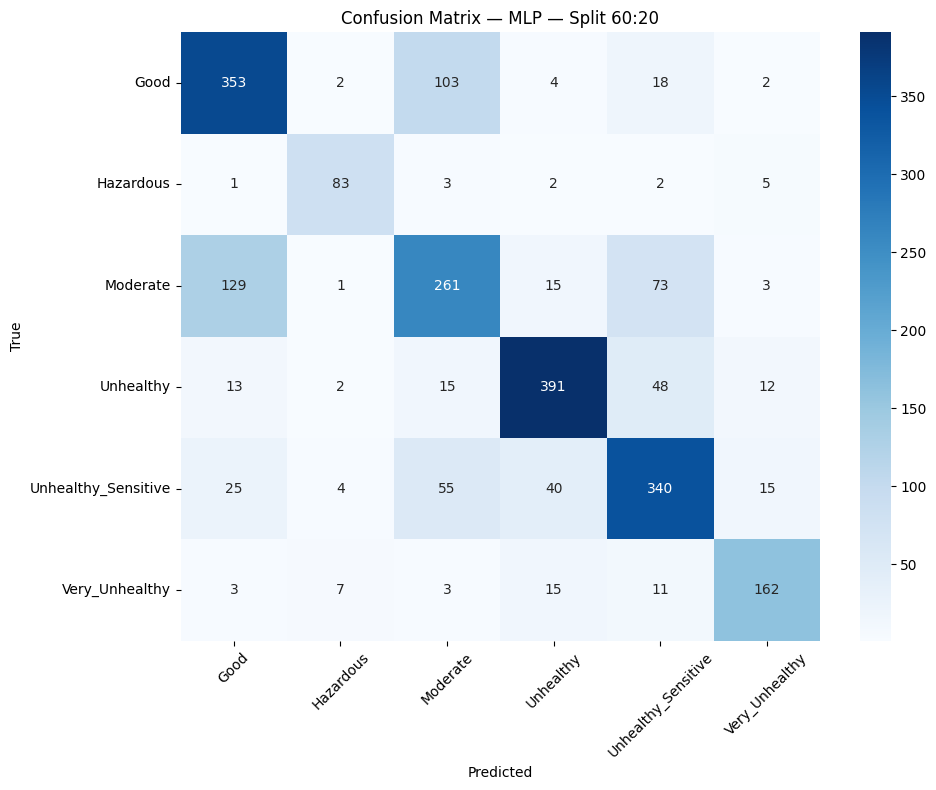


------------------------------
SVM — Split 60:20
------------------------------
Accuracy (SVM) — Split 60:20: 60.11%

Classification Report:
                     precision    recall  f1-score   support

               Good      0.623     0.718     0.667       482
          Hazardous      0.664     0.781     0.718        96
           Moderate      0.498     0.473     0.485       482
          Unhealthy      0.665     0.669     0.667       481
Unhealthy_Sensitive      0.556     0.516     0.535       479
     Very_Unhealthy      0.701     0.582     0.636       201

           accuracy                          0.601      2221
          macro avg      0.618     0.623     0.618      2221
       weighted avg      0.599     0.601     0.599      2221



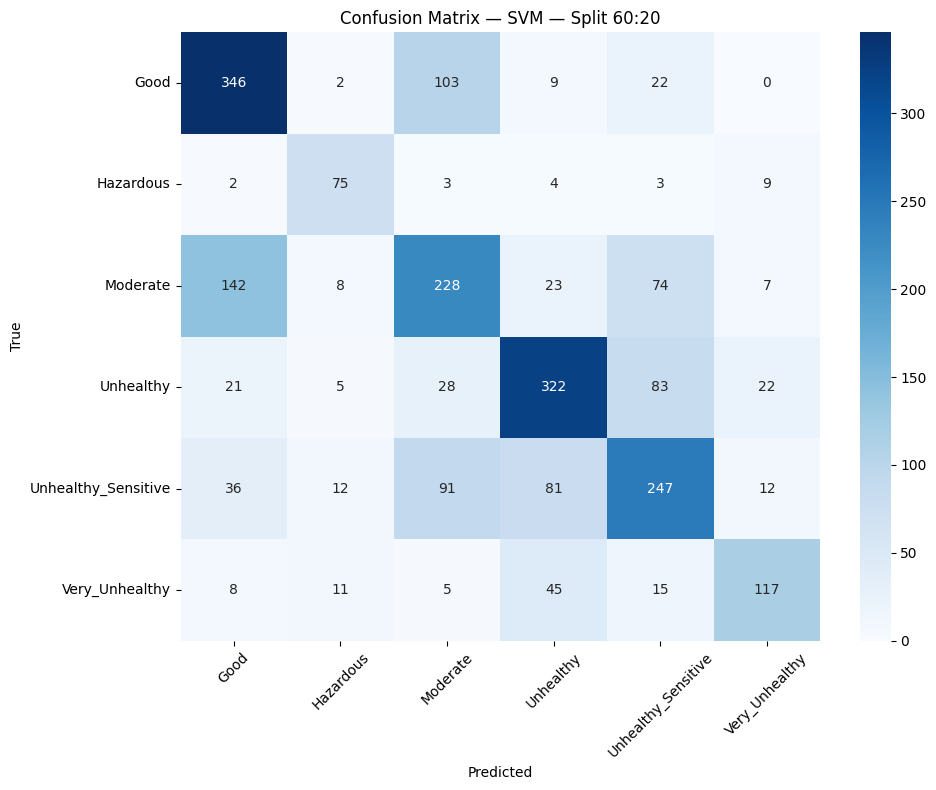


------------------------------
Decision Tree — Split 60:20
------------------------------
Accuracy (Decision Tree) — Split 60:20: 40.61%

Classification Report:
                     precision    recall  f1-score   support

               Good      0.436     0.446     0.441       482
          Hazardous      0.423     0.427     0.425        96
           Moderate      0.322     0.315     0.319       482
          Unhealthy      0.465     0.457     0.461       481
Unhealthy_Sensitive      0.385     0.386     0.385       479
     Very_Unhealthy      0.434     0.443     0.438       201

           accuracy                          0.406      2221
          macro avg      0.411     0.412     0.412      2221
       weighted avg      0.406     0.406     0.406      2221



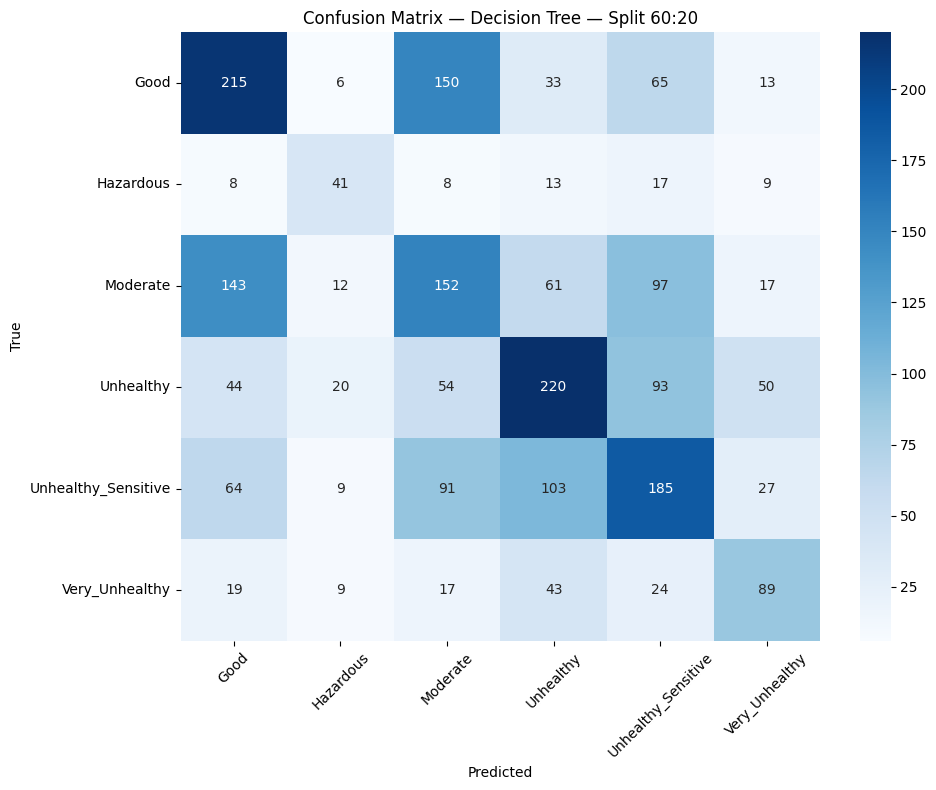


------------------------------
Random Forest — Split 60:20
------------------------------
Accuracy (Random Forest) — Split 60:20: 57.05%

Classification Report:
                     precision    recall  f1-score   support

               Good      0.535     0.720     0.614       482
          Hazardous      1.000     0.260     0.413        96
           Moderate      0.431     0.394     0.412       482
          Unhealthy      0.644     0.775     0.704       481
Unhealthy_Sensitive      0.570     0.530     0.549       479
     Very_Unhealthy      0.963     0.388     0.553       201

           accuracy                          0.570      2221
          macro avg      0.690     0.511     0.541      2221
       weighted avg      0.602     0.570     0.561      2221



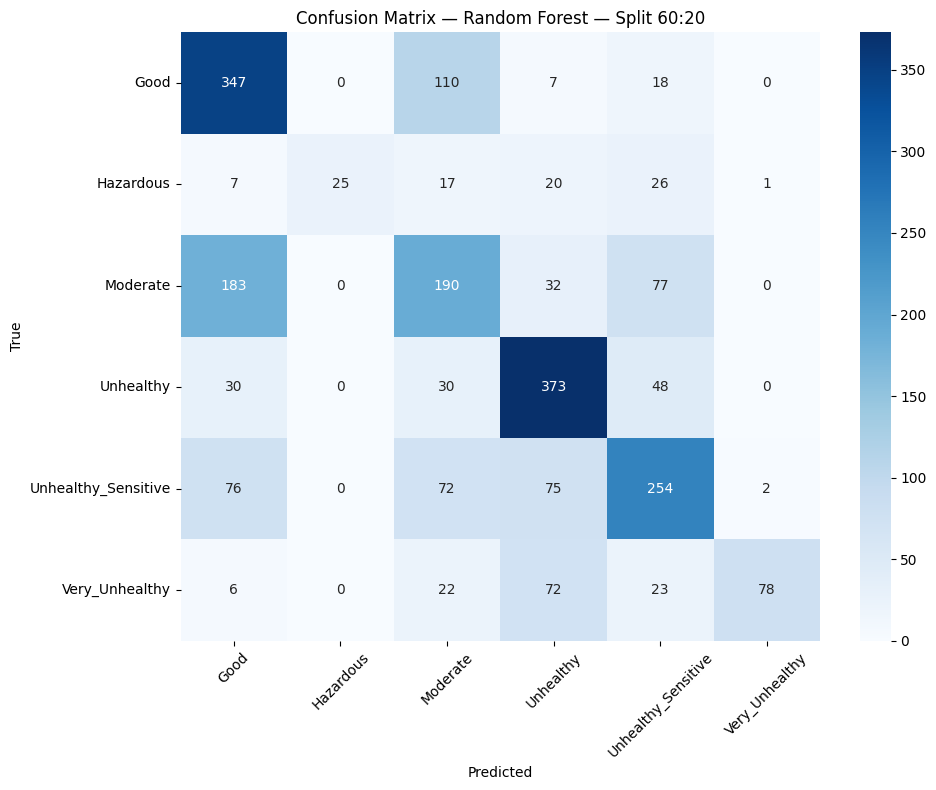

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n" + "="*90)
print(f"EVALUATION Confusion Matrix — Split {tr}:{te}")
print("="*90)

for name, model in classifiers.items():

    print(f"\n------------------------------")
    print(f"{name} — Split {tr}:{te}")
    print(f"------------------------------")

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    acc = accuracy_score(y_te, preds)
    print(f"Accuracy ({name}) — Split {tr}:{te}: {acc * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(
        y_te, preds,
        target_names=[idx_to_class[i] for i in range(NUM_CLASSES)],
        digits=3
    ))

    cm = confusion_matrix(y_te, preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)],
        yticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix — {name} — Split {tr}:{te}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

This block benchmarks the classical classifiers by re-fitting each one to measure training time, then computing and printing both training and validation accuracy for comparison. It stores timing and accuracy results in dictionaries, keeps the MLP’s training loss curve (since only MLP provides loss_curve_), and finally visualizes (1) training time as a bar chart, (2) validation accuracy as a bar chart, and (3) the MLP loss curve over iterations to show its optimization behavior.


TRAINING TIME + ACCURACY — Split 80:20

------------------------------
⏳ Evaluating: MLP (Split 80:20)
------------------------------
Training Time: 94.78 sec
Train Accuracy: 100.00%
Test Accuracy: 71.59%
Saved Model: saved_models_80_20/MLP_80_20.pkl

------------------------------
⏳ Evaluating: SVM (Split 80:20)
------------------------------
Training Time: 1474.32 sec
Train Accuracy: 79.86%
Test Accuracy: 60.11%
Saved Model: saved_models_80_20/SVM_80_20.pkl

------------------------------
⏳ Evaluating: Decision Tree (Split 80:20)
------------------------------
Training Time: 10.44 sec
Train Accuracy: 100.00%
Test Accuracy: 39.53%
Saved Model: saved_models_80_20/Decision_Tree_80_20.pkl

------------------------------
⏳ Evaluating: Random Forest (Split 80:20)
------------------------------
Training Time: 68.29 sec
Train Accuracy: 100.00%
Test Accuracy: 57.05%
Saved Model: saved_models_80_20/Random_Forest_80_20.pkl


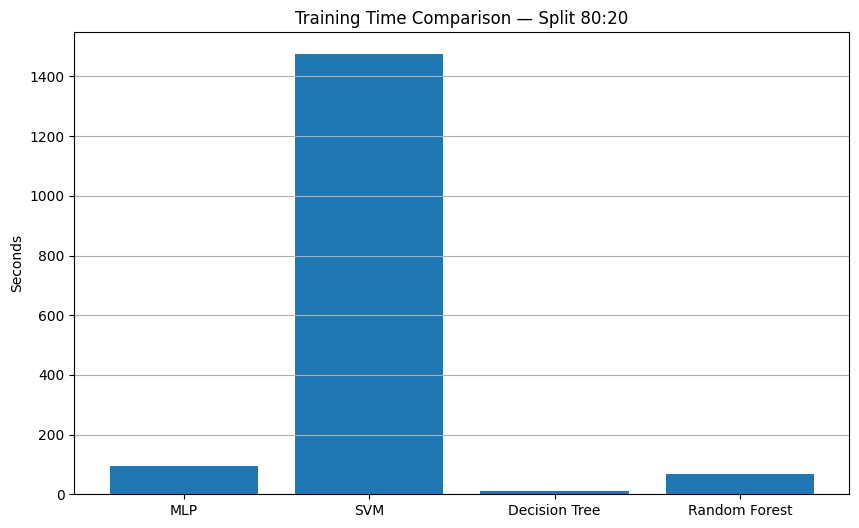

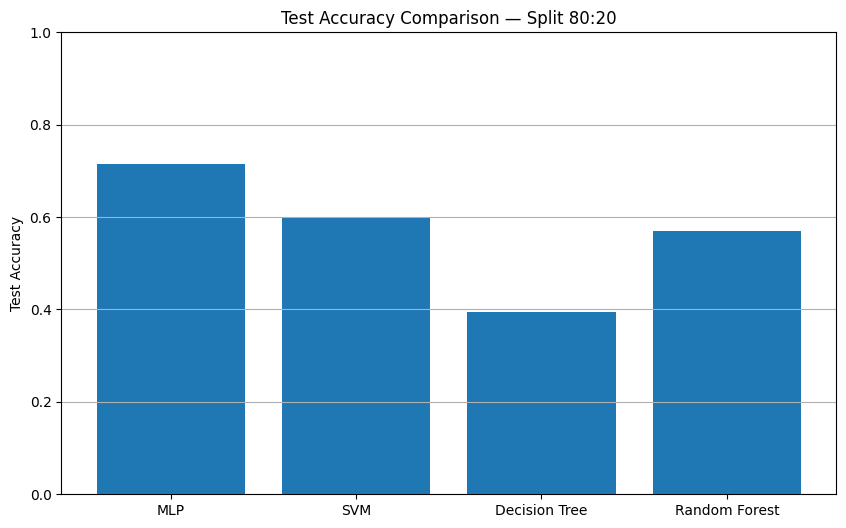

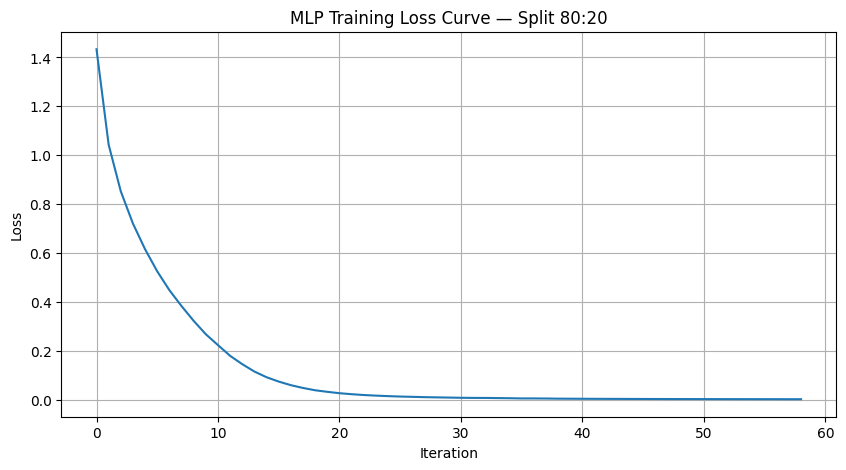

In [22]:
import time
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

tr, te = 80, 20

print("\n" + "="*90)
print(f"TRAINING TIME + ACCURACY — Split {tr}:{te}")
print("="*90)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all,
    test_size=te / 100,
    stratify=y_all,
    random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

pca = PCA(n_components=512)
X_tr = pca.fit_transform(X_tr)
X_te = pca.transform(X_te)

classifiers = {
    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation='relu',
        solver='adam',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42,
        verbose=False
    ),
    "SVM": SVC(kernel="linear", probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

save_dir = f"saved_models_{tr}_{te}"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(scaler, f"{save_dir}/scaler_{tr}_{te}.pkl")
joblib.dump(pca, f"{save_dir}/pca_{tr}_{te}.pkl")

train_times = {}
train_accuracies = {}
test_accuracies = {}
loss_curves = {}

for name, model in classifiers.items():

    print(f"\n------------------------------")
    print(f"⏳ Evaluating: {name} (Split {tr}:{te})")
    print(f"------------------------------")

    start = time.time()
    model.fit(X_tr, y_tr)
    end = time.time()

    model_filename = f"{save_dir}/{name.replace(' ', '_')}_{tr}_{te}.pkl"
    joblib.dump(model, model_filename)

    train_times[name] = end - start

    train_preds = model.predict(X_tr)
    test_preds = model.predict(X_te)

    train_acc = accuracy_score(y_tr, train_preds)
    test_acc = accuracy_score(y_te, test_preds)

    train_accuracies[name] = train_acc
    test_accuracies[name] = test_acc

    print(f"Training Time: {train_times[name]:.2f} sec")
    print(f"Train Accuracy: {train_acc*100:.2f}%")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Saved Model: {model_filename}")

    if name == "MLP":
        loss_curves[name] = model.loss_curve_
    else:
        loss_curves[name] = None

plt.figure(figsize=(10, 6))
plt.bar(train_times.keys(), train_times.values())
plt.ylabel("Seconds")
plt.title(f"Training Time Comparison — Split {tr}:{te}")
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(10, 6))
x = range(len(classifiers))
plt.bar(x, [test_accuracies[c] for c in classifiers], tick_label=list(classifiers.keys()))
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy Comparison — Split {tr}:{te}")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

if loss_curves["MLP"] is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(loss_curves["MLP"])
    plt.title(f"MLP Training Loss Curve — Split {tr}:{te}")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

In [23]:
import time
import joblib
import tempfile
import os
import pandas as pd
import numpy as np

efficiency_results = []

tr, te = 70, 30

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all,
    y_all,
    test_size=te / 100,
    stratify=y_all,
    random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

pca_components = min(512, X_tr.shape[0], X_tr.shape[1])
pca = PCA(n_components=pca_components)
X_tr = pca.fit_transform(X_tr)
X_te = pca.transform(X_te)

classifiers = {
    "MLP": MLPClassifier(
        hidden_layer_sizes=(1024, 512, 256),
        activation="relu",
        solver="adam",
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42,
        verbose=False
    ),
    "SVM": SVC(kernel="linear", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

save_dir = f"saved_models_{tr}_{te}"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(scaler, f"{save_dir}/scaler_{tr}_{te}.pkl")
joblib.dump(pca, f"{save_dir}/pca_{tr}_{te}.pkl")

for name, model in classifiers.items():

    model.fit(X_tr, y_tr)

    model_filename = f"{save_dir}/{name.replace(' ', '_')}_{tr}_{te}.pkl"
    joblib.dump(model, model_filename)

    start_time = time.time()
    preds = model.predict(X_te)
    end_time = time.time()

    total_inference_time = end_time - start_time
    avg_inference_time = total_inference_time / len(X_te)

    model_size_mb = os.path.getsize(model_filename) / (1024 * 1024)

    if name == "MLP":
        parameters = sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)
    elif name == "SVM":
        parameters = len(model.support_)
    elif name == "Decision Tree":
        parameters = model.tree_.node_count
    elif name == "Random Forest":
        parameters = sum(est.tree_.node_count for est in model.estimators_)
    else:
        parameters = "N/A"

    efficiency_results.append({
        "Split Ratio": f"{tr}:{te}",
        "Model": name,
        "Inference Time (sec)": round(total_inference_time, 4),
        "Avg Inference Time / Sample (ms)": round(avg_inference_time * 1000, 4),
        "Model Size (MB)": round(model_size_mb, 4),
        "Parameters / Complexity Count": parameters,
        "Saved Model Path": model_filename
    })

efficiency_df = pd.DataFrame(efficiency_results)
efficiency_df

,Split Ratio,Model,Inference Time (sec),Avg Inference Time / Sample (ms),Model Size (MB),Parameters / Complexity Count,Saved Model Path
0,70:30,MLP,0.0964,0.0289,18.0604,1182982,saved_models_70_30/MLP_70_30.pkl
1,70:30,SVM,6.4581,1.9388,20.9904,5265,saved_models_70_30/SVM_70_30.pkl
2,70:30,Decision Tree,0.0031,0.0009,0.3295,3073,saved_models_70_30/Decision_Tree_70_30.pkl
3,70:30,Random Forest,0.2043,0.0613,70.2457,656876,saved_models_70_30/Random_Forest_70_30.pkl


This block tests a cosine-distance k-NN classifier on the extracted feature vectors by training separate KNN models with different neighbor counts (k = 1, 5, 20). For each k, it fits on the training features, predicts the validation labels, computes validation accuracy, and prints the result to compare how k affects performance.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 5, 20]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(train_X, train_y)

    val_preds = knn.predict(val_X)
    acc = accuracy_score(val_y, val_preds)

    print(f"🔹 k = {k}: Validation Accuracy = {acc * 100:.2f}%")


🔹 k = 1: Validation Accuracy = 70.80%
🔹 k = 5: Validation Accuracy = 69.90%
🔹 k = 20: Validation Accuracy = 63.80%


This block measures label efficiency by repeatedly training classifiers on small random subsets of the training features (1%, 5%, 10%, 25%, 50%) and evaluating on the full validation set. For each fraction, it samples a subset with a fixed seed for reproducibility, trains four models (multinomial logistic regression as a linear probe, linear SVM, decision tree, and random forest), stores their validation accuracies, and finally plots accuracy vs. percentage of labeled data to compare how quickly each method improves as more labels are available.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fraction 1% complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fraction 5% complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fraction 10% complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fraction 25% complete.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fraction 50% complete.


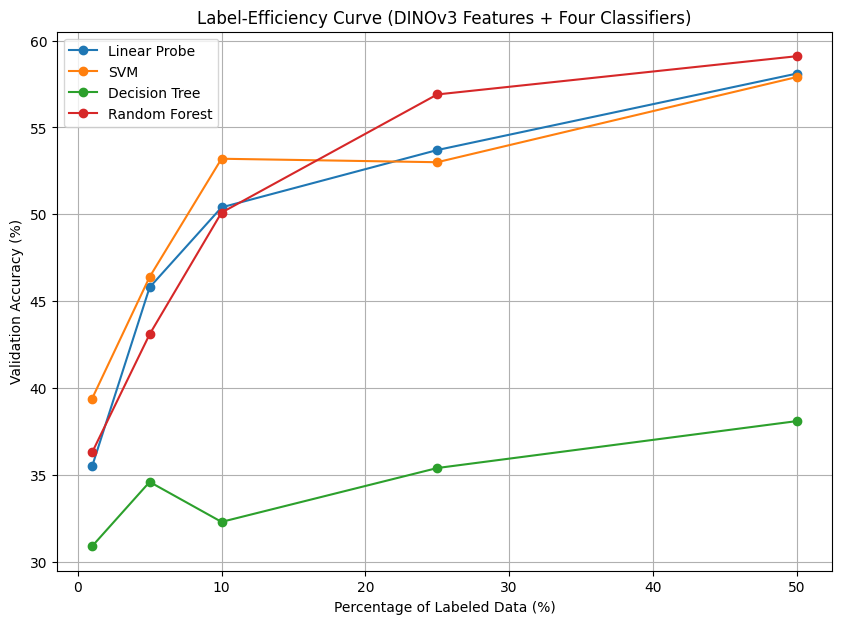

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
n_train = train_X.shape[0]

linear_probe_accuracies = []
svm_accuracies = []
dt_accuracies = []
rf_accuracies = []

for frac in fractions:
    n_samples = max(1, int(n_train * frac))
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    clf = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    )
    clf.fit(X_subset, y_subset)
    val_preds = clf.predict(val_X)
    linear_probe_accuracies.append(accuracy_score(val_y, val_preds))

    svm = SVC(kernel="linear", probability=True)
    svm.fit(X_subset, y_subset)
    svm_accuracies.append(accuracy_score(val_y, svm.predict(val_X)))

    dt = DecisionTreeClassifier()
    dt.fit(X_subset, y_subset)
    dt_accuracies.append(accuracy_score(val_y, dt.predict(val_X)))

    rf = RandomForestClassifier(n_estimators=200)
    rf.fit(X_subset, y_subset)
    rf_accuracies.append(accuracy_score(val_y, rf.predict(val_X)))

    print(f"Fraction {frac*100:.0f}% complete.")

plt.figure(figsize=(10,7))
plt.plot([f*100 for f in fractions], [x*100 for x in linear_probe_accuracies], marker='o', label="Linear Probe")
plt.plot([f*100 for f in fractions], [x*100 for x in svm_accuracies], marker='o', label="SVM")
plt.plot([f*100 for f in fractions], [x*100 for x in dt_accuracies], marker='o', label="Decision Tree")
plt.plot([f*100 for f in fractions], [x*100 for x in rf_accuracies], marker='o', label="Random Forest")

plt.xlabel("Percentage of Labeled Data (%)")
plt.ylabel("Validation Accuracy (%)")
plt.title("Label-Efficiency Curve (DINOv3 Features + Four Classifiers)")
plt.grid(True)
plt.legend()
plt.show()
